# Lesson 08 — Maximum Likelihood Estimation

<h2 dir="rtl">פרק 1 — חזרה משיעור 07</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import minimize_scalar

<h2 dir="rtl">פרק 2 — MLE על Bernoulli</h2>

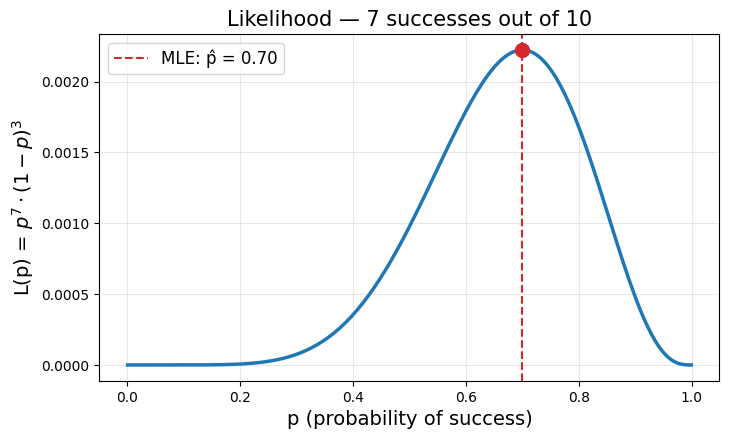

In [2]:
n_succ, n_fail = 7, 3
n_total = n_succ + n_fail

p_grid = np.linspace(0.001, 0.999, 200)
L = (p_grid ** n_succ) * ((1 - p_grid) ** n_fail)

p_hat_mle = n_succ / n_total
L_at_mle = (p_hat_mle ** n_succ) * ((1 - p_hat_mle) ** n_fail)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(p_grid, L, color='tab:blue', linewidth=2.5)
ax.axvline(p_hat_mle, color='tab:red', linestyle='--', label=f'MLE: p̂ = {p_hat_mle:.2f}')
ax.scatter([p_hat_mle], [L_at_mle], color='tab:red', s=100, zorder=5)
ax.set_xlabel('p (probability of success)', fontsize=14)
ax.set_ylabel(r'L(p) = $p^7 \cdot (1-p)^3$', fontsize=14)
ax.set_title('Likelihood — 7 successes out of 10', fontsize=15)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.show()

In [3]:
print(f'{"p":<8}{"L(p)":<16}{"log L(p)":<14}')
print('-' * 38)
for p in [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]:
    L_p = (p ** n_succ) * ((1 - p) ** n_fail)
    logL_p = n_succ * np.log(p) + n_fail * np.log(1 - p)
    marker = '  ← MLE' if abs(p - 0.7) < 1e-6 else ''
    print(f'{p:<8.2f}{L_p:<16.4e}{logL_p:<+14.3f}{marker}')

p       L(p)            log L(p)      
--------------------------------------
0.10    7.2900e-08      -16.434       
0.30    7.5014e-05      -9.498        
0.50    9.7656e-04      -6.931        
0.70    2.2236e-03      -6.109          ← MLE
0.90    4.7830e-04      -7.645        
0.99    9.3207e-07      -13.886       


<h2 dir="rtl">פרק 3 — מעבר ל-Logistic</h2>

In [4]:
data = pd.read_csv('oring.csv')
data['failure'] = (data['num_failure'] >= 1).astype(int)
X = data['temp'].values
y = data['failure'].values

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_likelihood(beta0, beta1, X, y):
    z = beta0 + beta1 * X
    p = sigmoid(z)
    eps = 1e-15
    return np.sum(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

print('Candidate values of (β₀, β₁) — log-likelihood on Challenger:')
print(f'{"β₀":>10}{"β₁":>10}{"log L":>12}')
print('-' * 32)
for b0, b1 in [(0, 0), (10, -0.15), (20, -0.30), (23.22, -0.358), (30, -0.45)]:
    ll = log_likelihood(b0, b1, X, y)
    marker = '  ← MLE-ish' if abs(b0 - 23.22) < 0.01 else ''
    print(f'{b0:>10.2f}{b1:>+10.3f}{ll:>+12.3f}{marker}')

Candidate values of (β₀, β₁) — log-likelihood on Challenger:
        β₀        β₁       log L
--------------------------------
      0.00    +0.000     -15.942
     10.00    -0.150      -9.526
     20.00    -0.300      -7.704
     23.22    -0.358      -7.072  ← MLE-ish
     30.00    -0.450      -7.503


<h2 dir="rtl">פרק 4 — קווי likelihood על Challenger</h2>

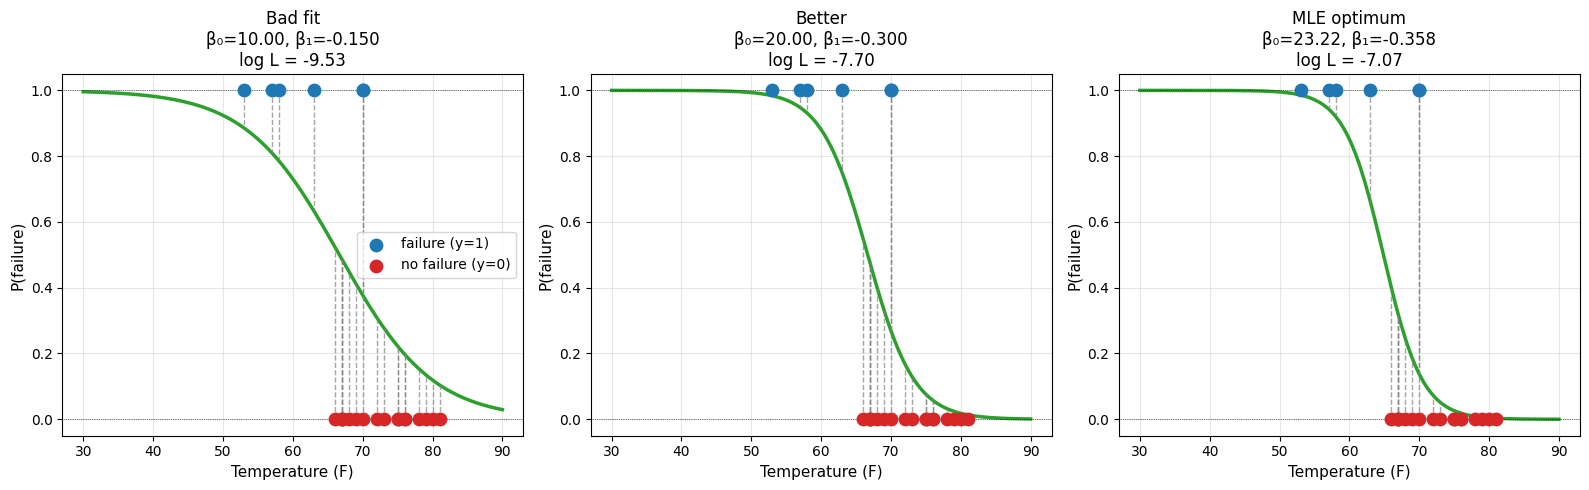

In [5]:
def plot_likelihood_lines(ax, beta0, beta1, X, y, title):
    x_grid = np.linspace(30, 90, 200)
    p_curve = sigmoid(beta0 + beta1 * x_grid)
    ax.plot(x_grid, p_curve, color='tab:green', linewidth=2.5)
    ax.scatter(X[y == 1], y[y == 1], color='tab:blue', s=80, zorder=5, label='failure (y=1)')
    ax.scatter(X[y == 0], y[y == 0], color='tab:red', s=80, zorder=5, label='no failure (y=0)')
    for xi, yi in zip(X, y):
        pi = sigmoid(beta0 + beta1 * xi)
        ax.plot([xi, xi], [yi, pi], color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ll = log_likelihood(beta0, beta1, X, y)
    ax.set_title(f'{title}\nβ₀={beta0:.2f}, β₁={beta1:+.3f}\nlog L = {ll:.2f}', fontsize=12)
    ax.set_xlabel('Temperature (F)', fontsize=11)
    ax.set_ylabel('P(failure)', fontsize=11)
    ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
    ax.axhline(1, color='black', linewidth=0.5, linestyle=':')
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_likelihood_lines(axes[0], 10, -0.15, X, y, title='Bad fit')
plot_likelihood_lines(axes[1], 20, -0.30, X, y, title='Better')
plot_likelihood_lines(axes[2], 23.22, -0.358, X, y, title='MLE optimum')
axes[0].legend(fontsize=10, loc='center right')
plt.tight_layout()
plt.show()

<h2 dir="rtl">פרק 5 — log-likelihood: למה log + עקומה 1D</h2>

In [6]:
print(f'{"n":<6}{"L":<16}{"log L":<12}')
print('-' * 34)
for n_size in [10, 50, 200, 1000]:
    k = int(n_size * 0.7)
    L_size = (0.7 ** k) * (0.3 ** (n_size - k))
    logL_size = k * np.log(0.7) + (n_size - k) * np.log(0.3)
    print(f'{n_size:<6}{L_size:<16.4e}{logL_size:<+12.2f}')

n     L               log L       
----------------------------------
10    2.2236e-03      -6.11       
50    5.4356e-14      -30.54      
200   8.7297e-54      -122.17     
1000  5.0700e-266     -610.86     


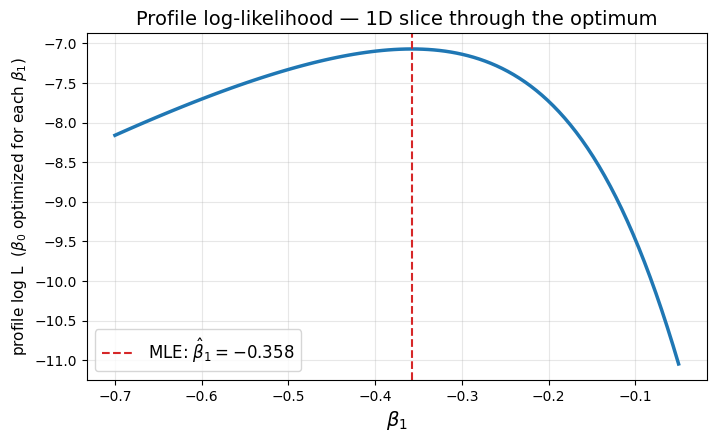

Maximum of profile: β₁ = -0.3586, log L = -7.0714


In [7]:
b1_grid = np.linspace(-0.7, -0.05, 100)
profile_ll = []
for b1 in b1_grid:
    res = minimize_scalar(lambda b0: -log_likelihood(b0, b1, X, y), bracket=(0, 50))
    profile_ll.append(-res.fun)
profile_ll = np.array(profile_ll)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(b1_grid, profile_ll, color='tab:blue', linewidth=2.5)
ax.axvline(-0.358, color='tab:red', linestyle='--', label=r'MLE: $\hat\beta_1 = -0.358$')
ax.set_xlabel(r'$\beta_1$', fontsize=14)
ax.set_ylabel(r'profile log L  ($\beta_0$ optimized for each $\beta_1$)', fontsize=11)
ax.set_title('Profile log-likelihood — 1D slice through the optimum', fontsize=14)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.show()

print(f'Maximum of profile: β₁ = {b1_grid[np.argmax(profile_ll)]:.4f}, log L = {profile_ll.max():.4f}')

<h2 dir="rtl">פרק 6 — Surface 2D של $\ell(\beta_0, \beta_1)$</h2>

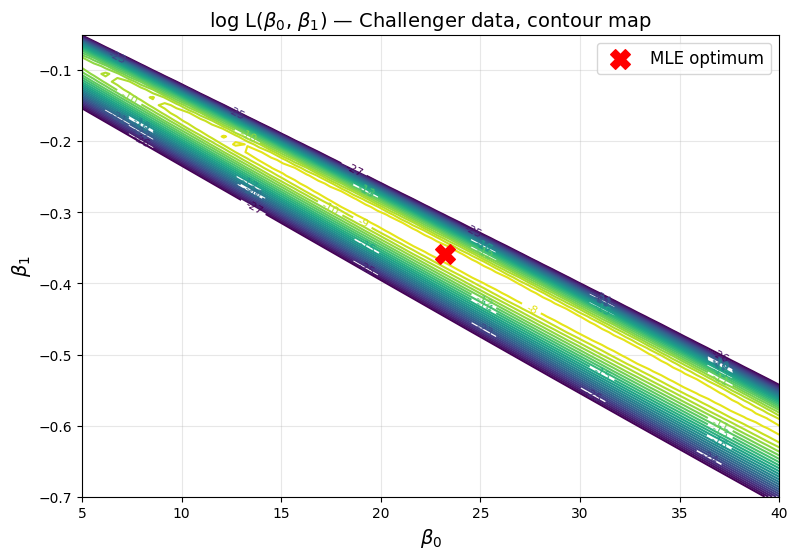

In [8]:
b0_grid = np.linspace(5, 40, 60)
b1_grid = np.linspace(-0.7, -0.05, 60)
B0, B1 = np.meshgrid(b0_grid, b1_grid)
LL_surface = np.zeros_like(B0)
for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        LL_surface[i, j] = log_likelihood(B0[i, j], B1[i, j], X, y)

fig, ax = plt.subplots(figsize=(9, 6))
levels = np.linspace(LL_surface.max() - 20, LL_surface.max(), 25)
cs = ax.contour(B0, B1, LL_surface, levels=levels, cmap='viridis')
ax.clabel(cs, inline=True, fontsize=8, fmt='%.0f')
ax.scatter([23.22], [-0.358], s=200, color='red', marker='X', zorder=5, label='MLE optimum')
ax.set_xlabel(r'$\beta_0$', fontsize=14)
ax.set_ylabel(r'$\beta_1$', fontsize=14)
ax.set_title(r'log L($\beta_0$, $\beta_1$) — Challenger data, contour map', fontsize=14)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.show()

<h2 dir="rtl">פרק 7 — Newton-Raphson: האופטימיזציה הנומרית</h2>

In [9]:
def gradient_logit(beta, X, y):
    z = beta[0] + beta[1] * X
    p = sigmoid(z)
    return np.array([np.sum(y - p), np.sum((y - p) * X)])

def hessian_logit(beta, X):
    z = beta[0] + beta[1] * X
    p = sigmoid(z)
    w = p * (1 - p)
    return np.array([
        [-np.sum(w),       -np.sum(w * X)],
        [-np.sum(w * X),   -np.sum(w * X * X)],
    ])

In [10]:
beta = np.array([0.0, 0.0])
iterations = [(0, beta.copy(), log_likelihood(beta[0], beta[1], X, y))]
for it in range(1, 7):
    g = gradient_logit(beta, X, y)
    H = hessian_logit(beta, X)
    beta = beta - np.linalg.solve(H, g)
    ll = log_likelihood(beta[0], beta[1], X, y)
    iterations.append((it, beta.copy(), ll))

print(f'{"iter":<6}{"β₀":>10}{"β₁":>10}{"log L":>12}')
print('-' * 38)
for it, b, ll in iterations:
    print(f'{it:<6}{b[0]:>10.4f}{b[1]:>+10.4f}{ll:>+12.4f}')

iter          β₀        β₁       log L
--------------------------------------
0         0.0000   +0.0000    -15.9424
1        10.4768   -0.1633     -8.3967
2        16.8633   -0.2615     -7.2938
3        21.3349   -0.3293     -7.0866
4        23.0371   -0.3549     -7.0715
5        23.2198   -0.3576     -7.0714
6        23.2216   -0.3576     -7.0714


<h2 dir="rtl">פרק 8 — השוואה ל-sm.Logit</h2>

In [11]:
data['intercept'] = 1
m_logit = sm.Logit(data['failure'], data[['intercept', 'temp']]).fit(disp=0)

print('Manual Newton-Raphson (last iteration):')
print(f'  β₀ = {beta[0]:.4f}, β₁ = {beta[1]:.4f}, log L = {iterations[-1][2]:.4f}')
print()
print('statsmodels sm.Logit:')
print(f'  β₀ = {m_logit.params["intercept"]:.4f}, β₁ = {m_logit.params["temp"]:.4f}, log L = {m_logit.llf:.4f}')

Manual Newton-Raphson (last iteration):
  β₀ = 23.2216, β₁ = -0.3576, log L = -7.0714

statsmodels sm.Logit:
  β₀ = 23.2216, β₁ = -0.3576, log L = -7.0714


<h2 dir="rtl">פרק 9 — סיכום + הצצה לשיעור 09</h2>

### Write your answer here.

<div dir="rtl">

תרגיל קצר להתאמן בבית:

- (א) הרץ את לולאת Newton-Raphson **משלך** עם נקודת התחלה $(\beta_0, \beta_1) = (5, -0.1)$ — האם מתכנס לאותו אופטימום?
- (ב) חשב $\log L$ בנקודה $(\beta_0, \beta_1) = (50, -0.7)$. למה הערך כל-כך נמוך?
- (ג) חזור על הניסוי עם $Y$ הפוך — כלומר $Y' = 1 - Y$. מה התוצאות החדשות של $\hat\beta$?

</div>